### **Setup y carga de datos**

In [52]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import joblib

In [53]:
# Carga de datasets limpios del EDA

df_cities = pd.read_csv('../data_sample/cost-of-living-variables-agregadas.csv')
df_circleloop = pd.read_csv('../data_sample/digital-nomad-index-cicleloop-clean.csv')
df_movingto = pd.read_csv('../data_sample/digital-nomad-index-movingto-clean.csv')

### **Preprocesado de variables**

In [54]:
# Agregar Cost of Living a nivel país (media de todas las ciudades)

num_cols = df_cities.select_dtypes(include='number').columns.tolist()
df_countries = df_cities.groupby('country_name')[num_cols].mean().reset_index()

In [55]:
# Añadir continente (moda por país)

country_continent = df_cities.groupby('country_name')['continent'].first().reset_index()
df_countries = df_countries.merge(country_continent, on='country_name')


In [56]:
# Añadir número de ciudades por país

city_count = df_cities.groupby('country_name').size().reset_index(name='city_count')
df_countries = df_countries.merge(city_count, on='country_name')

In [57]:
# Merge con Circleloop (inner join)

df_regression = df_countries.merge(df_circleloop, left_on='country_name', right_on='country', how='inner')

### **Análisis de colinealidad entre variables y selección para el modelo**

- El objetivo es predecir nuestro targe `digital_nomad_score`. 
- La predicción se basa en los indicadores de coste de vida, conectividad, bienestar...

In [58]:
# Selección de features para el modelo de regresión lineal 

# Excluimos: 
# 1. El propio target de digital_nomad_score. 
# 2. 'rank' como variable por forma parte del cálculo del propio score
# 3. Columnas de identificación como nombre de país, continente... 

exclude_cols = ['country_name', 'country', 'continent', 'data_quality_flag',
                'digital_nomad_score', 'rank', 'rank_x', 'rank_y', 'cluster_dominant']

feature_candidates = []

num_cols = df_regression.select_dtypes(include='number').columns

for c in num_cols:
    if c not in exclude_cols:
        feature_candidates.append(c)

print(f'Variables candidatas: {len(feature_candidates)}')

Variables candidatas: 69


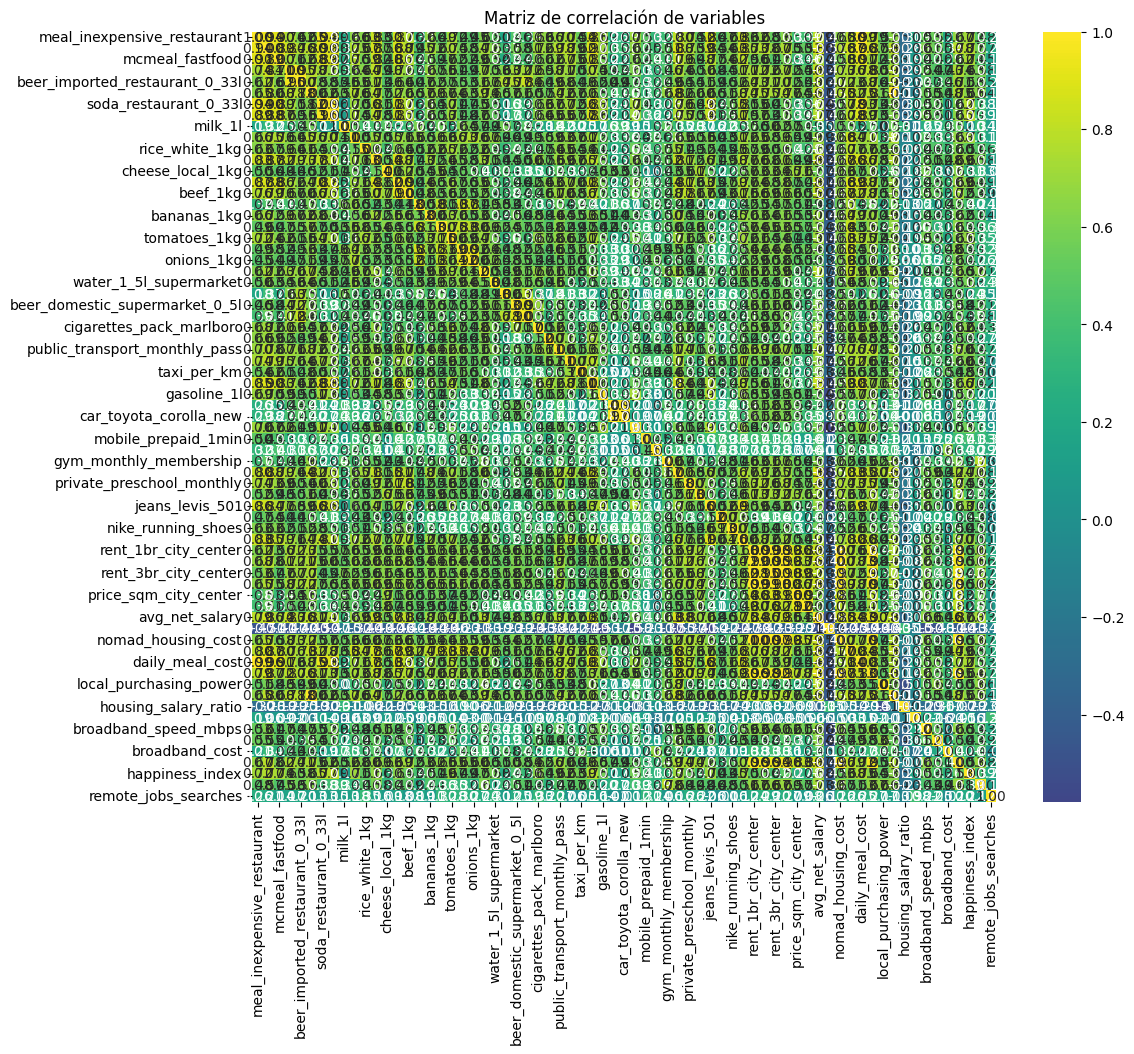

In [59]:
corr_matrix = df_regression[feature_candidates].corr()


plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,    
            fmt=".2f",       
            cmap='viridis', 
            center=0)        

plt.title("Matriz de correlación de variables")
plt.show()

In [60]:
# Creamos matriz de correlación

corr_matrix = df_regression[feature_candidates].corr().abs()

# Seleccionamos el triángulo superior de la matriz

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificamos columnas con correlación superior al umbral

to_drop = []

for column in upper.columns:
    if any(upper[column] > 0.8):
        to_drop.append(column)

# Eliminamos las variables

df_filtered = df_regression.drop(columns=to_drop)

In [61]:
# Variables que servirán para el cálculo del modelo de regresión

feature_candidates_reduced = []

for c in feature_candidates:
    if c not in to_drop:
        feature_candidates_reduced.append(c)

print(f'Variables tras reducción: {len(feature_candidates_reduced)}')

Variables tras reducción: 38


### **Creación del modelo de regresión**

In [62]:
target = ['digital_nomad_score'] # Elegimos el target

c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


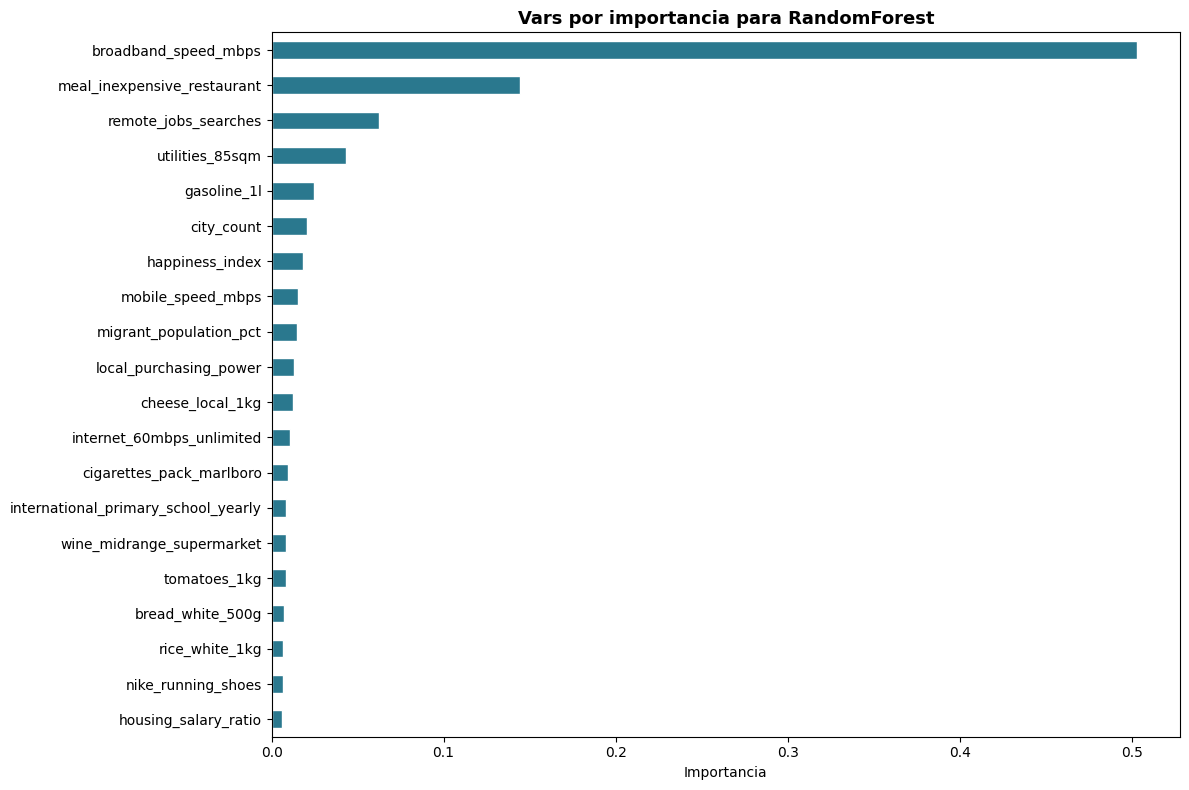

In [63]:
# Usamos un modelo RandomForest para elegir variables candidatas finales para el modelo

X_temp = df_regression[feature_candidates_reduced].fillna(0)
y_temp = df_regression[target]

rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=4)
rf_selector.fit(X_temp, y_temp)

importance = pd.Series(rf_selector.feature_importances_, index=feature_candidates_reduced).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
importance.head(20).sort_values().plot(kind='barh', ax=ax, color='#2A788E', edgecolor='white')
ax.set_title('Vars por importancia para RandomForest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

#### **Split entre train y test**

In [64]:
num_features = 12
selected_features = importance.head(num_features).index.tolist()
print(selected_features)

['broadband_speed_mbps', 'meal_inexpensive_restaurant', 'remote_jobs_searches', 'utilities_85sqm', 'gasoline_1l', 'city_count', 'happiness_index', 'mobile_speed_mbps', 'migrant_population_pct', 'local_purchasing_power', 'cheese_local_1kg', 'internet_60mbps_unlimited']


In [65]:
# Split entre train y test

X = df_regression[selected_features].fillna(0)
y = df_regression['digital_nomad_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} países ({X_train.shape[0]/len(X):.0%})')
print(f'Test:  {X_test.shape[0]} países ({X_test.shape[0]/len(X):.0%})')

Train: 64 países (79%)
Test:  17 países (21%)


<Figure size 2000x1500 with 0 Axes>

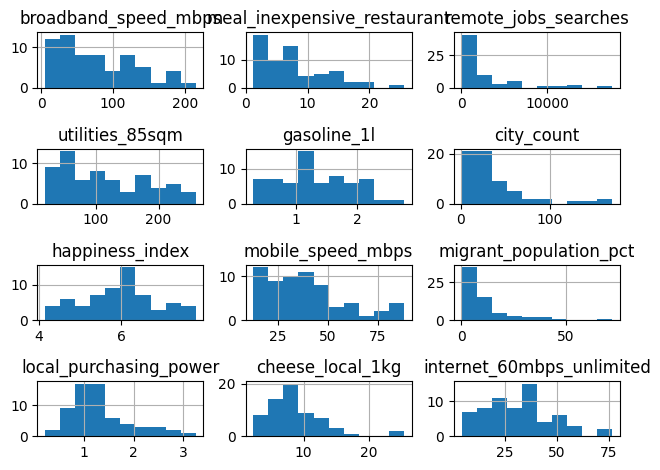

In [66]:
# Comprobamos si las variables van a necesitar escalado debido a la diferencia de magnitudes

plt.figure(figsize=(20, 15))
X_train.hist()
plt.tight_layout()
plt.show()

In [67]:
# El orden de magnitud nos obliga a escalar las variables 

scaler_regression = StandardScaler()
X_train_scaled = scaler_regression.fit_transform(X_train)
X_test_scaled = scaler_regression.transform(X_test)

In [68]:
# Usamos un modelo de regresión lineal como baseline

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

LinearRegression()

In [69]:
# Hacemos la predicción con los datos de test

y_pred_baseline_train = baseline_model.predict(X_train_scaled)
y_pred_baseline_test = baseline_model.predict(X_test_scaled)

In [70]:
# Sacamos las métricas principales del modelo baseline de regresión lineal 

print('Modelo de regresión lineal:')
print(f'  Train R²:  {r2_score(y_train, y_pred_baseline_train):.4f}')
print(f'  Test R²:   {r2_score(y_test, y_pred_baseline_test):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_baseline_test)):.2f}')
print(f'  Test MAE:  {mean_absolute_error(y_test, y_pred_baseline_test):.2f}')

Modelo de regresión lineal:
  Train R²:  0.8179
  Test R²:   0.7364
  Test RMSE: 5.95
  Test MAE:  4.43


In [71]:
# Validación cruzada con otros modelos de regresión para ponerlos a competir

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
    results.append({
        'Modelo': name,
        'CV R² (media)': scores.mean(),
        'CV R² (std)': scores.std()
    })

df_results = pd.DataFrame(results).sort_values('CV R² (media)', ascending=False)

In [72]:
print('Comparativa de modelos (Cross-Validation k=5)')
display(df_results.reset_index(drop=True))

Comparativa de modelos (Cross-Validation k=5)


,Modelo,CV R² (media),CV R² (std)
0,Ridge,0.707924,0.059762
1,Linear Regression,0.699065,0.065025
2,Random Forest,0.688866,0.072172
3,Lasso,0.687007,0.087315
4,ElasticNet,0.681043,0.060379
5,Gradient Boosting,0.676848,0.096178
6,SVR,0.246574,0.174168


- En principio el modelo ganador sería Ridge. 
- Lo seguirían los modelos de regresión lineal (baseline) y Random Forest. 

In [73]:
# Vamos a ajustar los modelos de Ridge y Random Foreest con hiperparámetros

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
parametros_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}

grid_ridge = GridSearchCV(ridge, 
                          parametros_ridge, 
                          cv=5)
grid_ridge.fit(X_train_scaled, y_train)

print(f"Mejor alpha para Ridge: {grid_ridge.best_params_}")
print(f"Mejor CV R²: {grid_ridge.best_score_:.4f}")

Mejor alpha para Ridge: {'alpha': 10.0}
Mejor CV R²: 0.7267


- Al ajustar Ridge con hiperparámetros hemos mejorado algo la métrica. 

In [74]:
rf = RandomForestRegressor(random_state=42)
parametros_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
    }

grid_rf = GridSearchCV(rf, 
                       parametros_rf, 
                       cv=5, 
                       n_jobs=-1) 
grid_rf.fit(X_train_scaled, y_train)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Mejor CV R²: {grid_rf.best_score_:.4f}")

Mejores parámetros RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Mejor CV R²: 0.6876


- Random Forest no mejora en exceso. 

In [75]:
# Probamos a ajustar Lasso 

lasso = Lasso(random_state=42)

parametros_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    }

grid_lasso = GridSearchCV(lasso, 
                          parametros_lasso, 
                          cv=5, 
                          scoring='r2')


grid_lasso.fit(X_train_scaled, y_train)

print(f"Mejor valor de alpha para Lasso: {grid_lasso.best_params_}")
print(f"Mejor CV R²: {grid_lasso.best_score_:.4f}")

Mejor valor de alpha para Lasso: {'alpha': 0.1}
Mejor CV R²: 0.7076


- Lasso si mejora con el ajuste con hiperparámetros. Aunque por debajo de Ridge

### **Probamos el modelo ganador contra test**

In [76]:
# Predicción contra test 

y_pred = grid_ridge.predict(X_test_scaled)

In [77]:
# Comparación de métricas 

# Calculamos R2 (proporción de varianza explicada)

r2_test = r2_score(y_test, y_pred)

# Calculamos el error cuadrático medio (MSE) y su raíz (RMSE)

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)

# Calculamos el error absoluto medio (MAE)

mae_test = mean_absolute_error(y_test, y_pred)

print(f"R² en Test: {r2_test:.4f}")
print(f"RMSE en Test: {rmse_test:.4f}")
print(f"MAE en Test: {mae_test:.4f}")

R² en Test: 0.8228
RMSE en Test: 4.8789
MAE en Test: 4.0444


In [78]:
# Países peor predichos (mayores errores)

test_countries = df_regression.iloc[X_test.index][['country_name']].copy()
test_countries['real'] = y_test.values
test_countries['prediccion'] = y_pred
test_countries['error_abs'] = np.abs(y_test.values - y_pred)
test_countries = test_countries.sort_values('error_abs', ascending=False)

print('Top 5 países con mayor error de predicción')
display(test_countries.head(5).reset_index(drop=True))

print('Predicciones completas en test')
display(test_countries.sort_values('real', ascending=False).reset_index(drop=True))

Top 5 países con mayor error de predicción


,country_name,real,prediccion,error_abs
0,Canada,74.35,84.684569,10.334569
1,Ghana,30.36,40.287718,9.927718
2,Ireland,53.15,59.065084,5.915084
3,Albania,38.97,44.361495,5.391495
4,El Salvador,36.60,41.886470,5.286470


Predicciones completas en test


,country_name,real,prediccion,error_abs
0,Canada,74.35,84.684569,10.334569
1,Sweden,61.54,60.697485,0.842515
2,Denmark,61.49,63.819978,2.329978
3,Hungary,59.12,55.999661,3.120339
4,Luxembourg,59.06,56.216605,2.843395
5,Singapore,58.76,60.721020,1.961020
6,Austria,57.31,55.528454,1.781546
7,Slovakia,54.39,52.622158,1.767842
8,Ireland,53.15,59.065084,5.915084
9,Mexico,52.08,50.118733,1.961267


### **Guardamos el modelo de regresión**

In [79]:
best_model = grid_ridge.best_estimator_

joblib.dump(best_model, '../models/regressor_nomad_score.joblib')
joblib.dump(scaler_regression, '../models/scaler_regression.joblib')

['../models/scaler_regression.joblib']